In [206]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)

In [207]:
outlets = pd.read_csv("Data/QSR_outlet_dataset_cleaned.csv", keep_default_na=False)
socioeconomic = pd.read_csv("Data/QSR_socioeconomic_dataset_cleaned.csv")

In [208]:
print("Outlet dataset shape:", outlets.shape)
print("Socioeconomic dataset shape:", socioeconomic.shape)

Outlet dataset shape: (2816, 17)
Socioeconomic dataset shape: (20, 9)


In [209]:
ml_data = outlets.merge(socioeconomic, on="Region", how="left")

print("Merged ML dataset shape:", ml_data.shape)
ml_data.head()

Merged ML dataset shape: (2816, 25)


,Outlet ID,Brand,Region,Province,Province_Shorthand,City,Menu_Category,Price_Range,Customer_Rating,Review_Count,Latitude,Longitude,Location_Type,Address,Source,Price_Range_Cleaned,Price_Range_Imputed,Province_Count,Region_Area,Population,Population Density,Disposable Income per capita,Total Tourism Flow,Foreign Tourism Flow,Median Income
0,1,McDonald's,Valle d'Aosta,Aosta,AO,Aosta,Burgers,EUR 1-10,3.800,3974,45.740,7.345,Commercial Area,"Aosta, 11100 Aosta, Aosta Valley",https://www.mcdonalds.it/elenco-ristoranti,EUR 1-10,False,1,3260.900,122554,37.600,25152,3692878.000,1439669.000,32900
1,2,McDonald's,Liguria,Genova,GE,Genova,Burgers,EUR 1-10,3.700,2244,44.407,8.937,City Center,Via Venti Settembre 1,https://www.mcdonalds.it/elenco-ristoranti,EUR 1-10,False,4,5416.210,1511988,279.200,25085,16084210.000,7238928.000,28085
2,3,McDonald's,Liguria,Genova,GE,Genova,Burgers,EUR 1-10,3.900,2170,44.414,8.880,Shopping Mall,"Via Paolo Mantovani, 17, 16149 Genova GE",https://www.mcdonalds.it/elenco-ristoranti,EUR 1-10,False,4,5416.210,1511988,279.200,25085,16084210.000,7238928.000,28085
3,4,McDonald's,Liguria,Genova,GE,Genova,Burgers,EUR 1-10,2.900,303,44.417,8.921,Transport Hub,"Piazza Acquaverde, 16134 Genova GE",https://www.mcdonalds.it/elenco-ristoranti,EUR 1-10,False,4,5416.210,1511988,279.200,25085,16084210.000,7238928.000,28085
4,5,McDonald's,Liguria,Genova,GE,Genova,Burgers,EUR 1-10,3.800,3290,44.411,8.929,Transport Hub,"Via di Sottoripa, 127R/133, 16124 Genova GE",https://www.mcdonalds.it/elenco-ristoranti,EUR 1-10,False,4,5416.210,1511988,279.200,25085,16084210.000,7238928.000,28085


In [210]:
print("Missing Review_Count values:", ml_data["Review_Count"].isna().sum())

Missing Review_Count values: 0


In [211]:
brand_median_reviews = ml_data.groupby("Brand")["Review_Count"].transform("median")
ml_data["High_Engagement"] = (ml_data["Review_Count"] > brand_median_reviews).astype(int)

print("High_Engagement counts:")
print(ml_data["High_Engagement"].value_counts(), ml_data["High_Engagement"].value_counts(normalize=True) * 100)

High_Engagement counts:
High_Engagement
0    1413
1    1403
Name: count, dtype: int64 High_Engagement
0   50.178
1   49.822
Name: proportion, dtype: float64


In [212]:
location_engagement = (
    ml_data.groupby("Location_Type")["High_Engagement"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

location_engagement

,count,mean
Location_Type,,
City Center,250,0.584
Service Area,365,0.564
Residential Area,67,0.552
Commercial Area,999,0.519
Shopping Mall,910,0.448
Transport Hub,225,0.391


In [213]:
print("Outlet count by brand:")
print(ml_data.groupby("Brand").size().sort_values())

Outlet count by brand:
Brand
Subway                    9
Five Guys                10
Burgez                   10
Spizzico                 14
Popeyes                  15
Spontini                 25
Starbucks                48
Billy Tacos              69
Chef Express             99
KFC                     153
Roadhouse Restaurant    168
Burger King             177
Alice Pizza             180
Old Wild West           243
Autogrill               278
La Piadineria           528
McDonald's              790
dtype: int64


In [214]:
categorical_features = [
    "Brand",
    "Menu_Category",
    "Price_Range_Cleaned",
    "Location_Type",
    "Region"
]

numeric_features = [
    "Latitude",
    "Longitude",
    "Population",
    "Population Density",
    "Disposable Income per capita",
    "Total Tourism Flow"
]

features = categorical_features + numeric_features

features

['Brand',
 'Menu_Category',
 'Price_Range_Cleaned',
 'Location_Type',
 'Region',
 'Latitude',
 'Longitude',
 'Population',
 'Population Density',
 'Disposable Income per capita',
 'Total Tourism Flow']

In [215]:
X = ml_data[features].copy()
y = ml_data["High_Engagement"].copy()

In [216]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature matrix:", X_train.shape)
print("Test feature matrix:", X_test.shape)

Training feature matrix: (2252, 11)
Test feature matrix: (564, 11)


In [217]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
High_Engagement
0   50.178
1   49.822
Name: proportion, dtype: float64

Test target distribution:
High_Engagement
0   50.177
1   49.823
Name: proportion, dtype: float64


In [218]:
ml_data[features + ["High_Engagement"]].isna().sum()

Brand                           0
Menu_Category                   0
Price_Range_Cleaned             0
Location_Type                   0
Region                          0
Latitude                        0
Longitude                       0
Population                      0
Population Density              0
Disposable Income per capita    0
Total Tourism Flow              0
High_Engagement                 0
dtype: int64

In [219]:
# Preparing the data
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("num", numeric_transformer, numeric_features)
])

In [220]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression( max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

In [221]:
logistic_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Models trained successfully")

Models trained successfully


In [222]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
    }

    return results

In [223]:
model_results = []

model_results.append(evaluate_model("Random Forest", rf_pipeline, X_test, y_test))
model_results.append(evaluate_model("Logistic Regression", logistic_pipeline, X_test, y_test))

In [224]:
model_results = pd.DataFrame(model_results).round(3)

model_results

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.590,0.585,0.612,0.598
1,Logistic Regression,0.527,0.522,0.587,0.553


From this table of results we can see that Random Forest is the better model, although it is slightly.

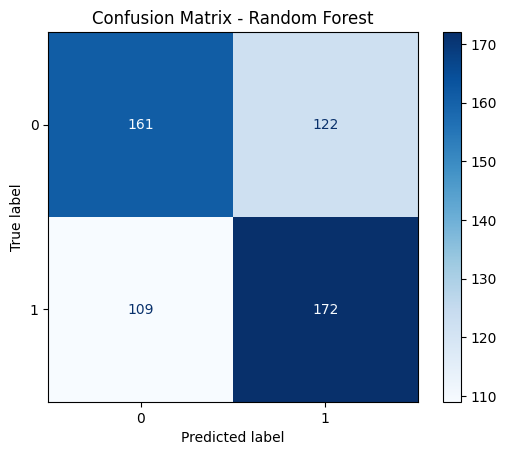

In [225]:
# Confusion matrix for the best model by F1-score

y_pred_best = rf_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap= "Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

This machine learning notebook tests whether some outlet characteristics and regional socioeconomic indicators can help classify outlets with higher public customer engagement.

The target variable, High_Engagement, was created by comparing each outlet’s review count with the median review count of its own brand.

The best-performing model was Random Forest, with an F1-score of 0.598. The model used brand, menu category, price range, location type, geographic variables, and regional socioeconomic indicators as predictors.

The result suggests that customer engagement is not explained by one factor alone. Instead, it appears to be associated with a combination of brand, outlet context, menu category, and geographic location.